In [11]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

df = pd.read_csv('howpop_train.csv')

C:\Users\011ko\AppData\Local\Temp\ipykernel_15400\3989794380.py:5: DtypeWarning: Columns (6,7,11,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('howpop_train.csv')


In [14]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134137 entries, 0 to 134136
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   url               134137 non-null  object 
 1   domain            134137 non-null  object 
 2   post_id           134137 non-null  int64  
 3   published         134137 non-null  object 
 4   author            97663 non-null   object 
 5   flow              97048 non-null   object 
 6   polling           134137 non-null  object 
 7   content_len       134137 non-null  object 
 8   title             134136 non-null  object 
 9   comments          134137 non-null  int64  
 10  favs              134137 non-null  int64  
 11  views             134137 non-null  object 
 12  votes_plus        133566 non-null  object 
 13  votes_minus       133566 non-null  object 
 14  views_lognorm     134137 non-null  object 
 15  favs_lognorm      134137 non-null  object 
 16  comments_lognorm  13

In [15]:
df.drop(
    filter(lambda c: c.endswith("_lognorm"), df.columns),
    axis=1,
    inplace=True,
)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134137 entries, 0 to 134136
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   url          134137 non-null  object 
 1   domain       134137 non-null  object 
 2   post_id      134137 non-null  int64  
 3   published    134137 non-null  object 
 4   author       97663 non-null   object 
 5   flow         97048 non-null   object 
 6   polling      134137 non-null  object 
 7   content_len  134137 non-null  object 
 8   title        134136 non-null  object 
 9   comments     134137 non-null  int64  
 10  favs         134137 non-null  int64  
 11  views        134137 non-null  object 
 12  votes_plus   133566 non-null  object 
 13  votes_minus  133566 non-null  object 
 14  Unnamed: 17  6 non-null       object 
 15  Unnamed: 18  0 non-null       float64
dtypes: float64(1), int64(3), object(12)
memory usage: 16.4+ MB
None


In [16]:
df["published"] = pd.to_datetime(df["published"], yearfirst=True)

In [17]:
df["year"] = [d.year for d in df.published]
df["month"] = [d.month for d in df.published]
df["dayofweek"] = [d.isoweekday() for d in df.published]
df["hour"] = [d.hour for d in df.published]

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134137 entries, 0 to 134136
Data columns (total 20 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   url          134137 non-null  object        
 1   domain       134137 non-null  object        
 2   post_id      134137 non-null  int64         
 3   published    134137 non-null  datetime64[ns]
 4   author       97663 non-null   object        
 5   flow         97048 non-null   object        
 6   polling      134137 non-null  object        
 7   content_len  134137 non-null  object        
 8   title        134136 non-null  object        
 9   comments     134137 non-null  int64         
 10  favs         134137 non-null  int64         
 11  views        134137 non-null  object        
 12  votes_plus   133566 non-null  object        
 13  votes_minus  133566 non-null  object        
 14  Unnamed: 17  6 non-null       object        
 15  Unnamed: 18  0 non-null       floa

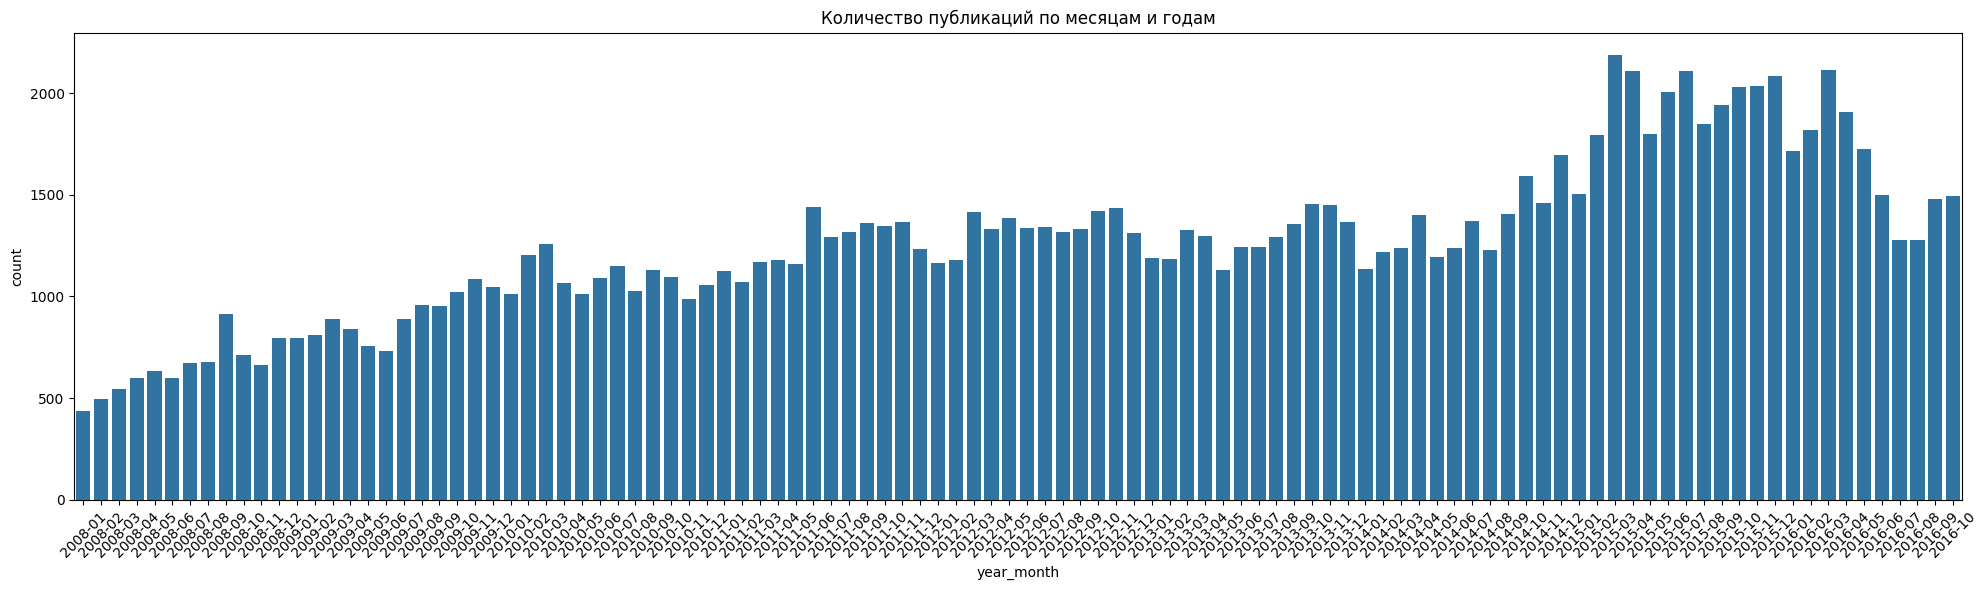

Больше всего публикаций было в 3.2015: 2189 публикаций


In [21]:
plt.figure(figsize=(20, 6))
month_year_counts = df.groupby(['year', 'month']).size().reset_index(name='count')
month_year_counts['year_month'] = month_year_counts['year'].astype(str) + '-' + month_year_counts['month'].astype(str).str.zfill(2)

sb.barplot(data=month_year_counts, x='year_month', y='count')
plt.title('Количество публикаций по месяцам и годам')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

max_month = month_year_counts.loc[month_year_counts['count'].idxmax()]
print(f"Больше всего публикаций было в {max_month['month']}.{max_month['year']}: {max_month['count']} публикаций")


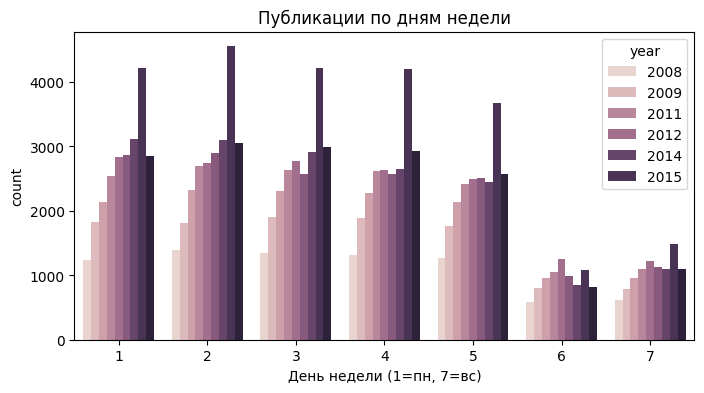

In [22]:
plt.figure(figsize=(8,4))
sb.countplot(x='dayofweek', hue='year', data=df)
plt.xlabel('День недели (1=пн, 7=вс)')
plt.title('Публикации по дням недели')
plt.show()

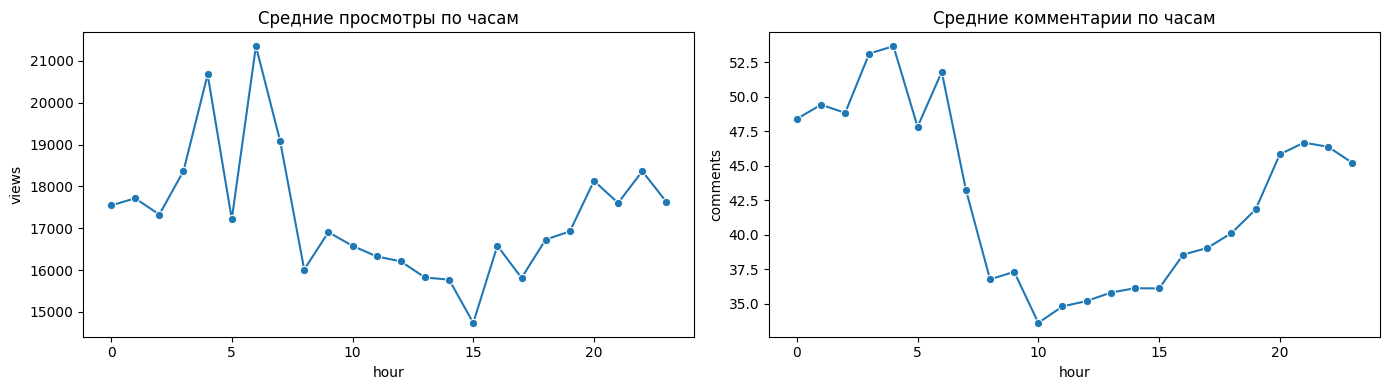

In [24]:
df['part_of_day'] = pd.cut(df['hour'],
                           bins=[0,6,12,18,24],
                           labels=['night','morning','day','evening'],
                           include_lowest=True)

df['views'] = pd.to_numeric(df['views'],    errors='coerce')
df['comments'] = pd.to_numeric(df['comments'], errors='coerce')

hourly = df.groupby('hour')[['views','comments']].mean().reset_index()

plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
sb.lineplot(x='hour', y='views', data=hourly, marker='o')
plt.title('Средние просмотры по часам')

plt.subplot(1,2,2)
sb.lineplot(x='hour', y='comments', data=hourly, marker='o')
plt.title('Средние комментарии по часам')

plt.tight_layout()
plt.show()

C:\Users\011ko\AppData\Local\Temp\ipykernel_10824\3537822566.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neg.values, y=neg.index, palette='Reds_r')


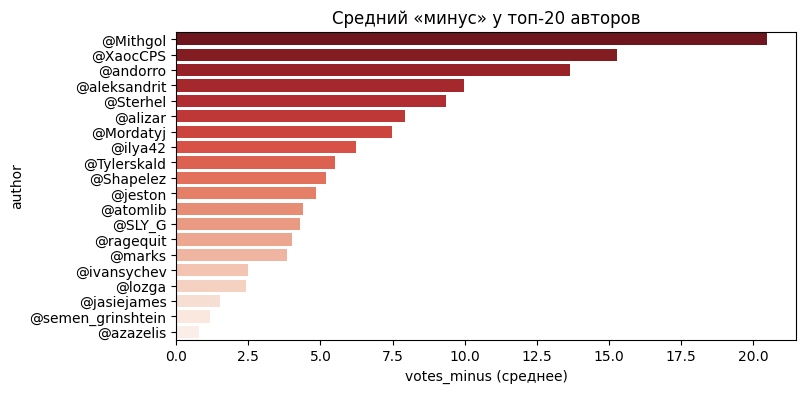

In [ ]:
df['votes_minus'] = df['votes_minus'].astype(str).str.replace(',', '.', regex=False)

df['votes_minus'] = pd.to_numeric(df['votes_minus'], errors='coerce')

top20 = df['author'].value_counts().head(20).index
df_top = df[df['author'].isin(top20)]

neg = (df_top.groupby('author')['votes_minus']
             .mean()
             
             .sort_values(ascending=False))

plt.figure(figsize=(8,4))
sb.barplot(x=neg.values, y=neg.index, palette='Reds_r')
plt.title('Средний «минус» у топ-20 авторов')
plt.xlabel('votes_minus (среднее)')
plt.show()

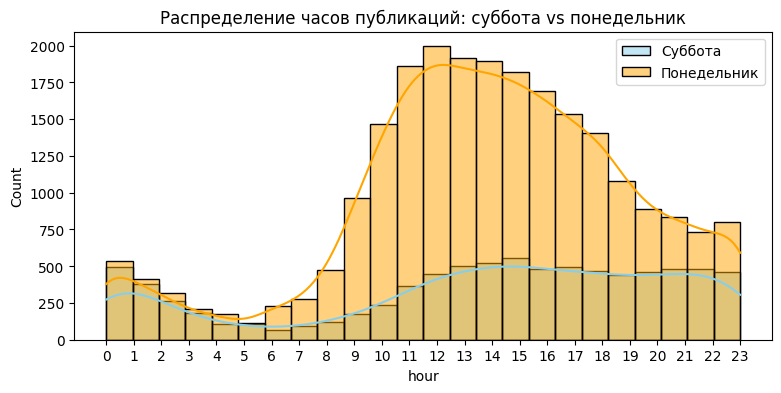

In [ ]:
sat = df[df['dayofweek']==6]['hour']
mon = df[df['dayofweek']==1]['hour']

plt.figure(figsize=(9,4))
sb.histplot(sat, bins=24, kde=True, label='Суббота', color='skyblue')
sb.histplot(mon, bins=24, kde=True, label='Понедельник', color='orange')
plt.xticks(range(0,24))
plt.legend()
plt.title('Распределение часов публикаций: суббота vs понедельник')
plt.show()